# Exploratory Data Analysis (EDA)

## Credit Risk Probability Model for Alternative Data

### Objective

The purpose of this analysis is to understand the structure, quality, and behavioral patterns within the Xente transaction dataset. The findings from this exploration will guide feature engineering, proxy target creation, and model development for the credit risk scoring system.

### Key Questions

1. What is the overall structure and quality of the data?
2. Are there missing values or data quality issues?
3. What customer and transaction patterns exist?
4. Which variables may be useful for credit risk prediction?
5. What insights can inform RFM-based segmentation?

In [3]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [5]:
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.00,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.00,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.00,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.00,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.00,644,2018-11-15T03:34:21Z,2,0


In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 95,662
Columns: 16


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

In [8]:
df.sample(5)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
33596,TransactionId_64096,BatchId_84556,AccountId_10,SubscriptionId_4346,CustomerId_4406,UGX,256,ProviderId_4,ProductId_10,airtime,ChannelId_5,-500.00,500,2018-12-20T09:23:36Z,4,0
64037,TransactionId_43351,BatchId_38253,AccountId_3474,SubscriptionId_1806,CustomerId_3910,UGX,256,ProviderId_5,ProductId_15,financial_services,ChannelId_3,10000.00,10000,2019-01-18T12:59:36Z,2,0
77182,TransactionId_129390,BatchId_26939,AccountId_4841,SubscriptionId_3829,CustomerId_4033,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-125.00,125,2019-01-29T09:56:04Z,2,0
74860,TransactionId_128823,BatchId_41339,AccountId_4319,SubscriptionId_770,CustomerId_4775,UGX,256,ProviderId_5,ProductId_3,airtime,ChannelId_3,1000.00,1000,2019-01-27T10:48:55Z,4,0
22239,TransactionId_18011,BatchId_96594,AccountId_3210,SubscriptionId_3348,CustomerId_3638,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,700.00,700,2018-12-10T11:27:25Z,2,0


In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


### Observation

The dataset consists of transaction-level records. Since credit risk is assessed at the customer level, transactions will eventually need to be aggregated by customer before model training.

In [10]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (
        df.isnull().mean()*100
    ).round(2)
})

missing.sort_values(
    "Percentage",
    ascending=False
)

,Missing Values,Percentage
TransactionId,0,0.00
BatchId,0,0.00
AccountId,0,0.00
SubscriptionId,0,0.00
CustomerId,0,0.00
CurrencyCode,0,0.00
CountryCode,0,0.00
ProviderId,0,0.00
ProductId,0,0.00
ProductCategory,0,0.00


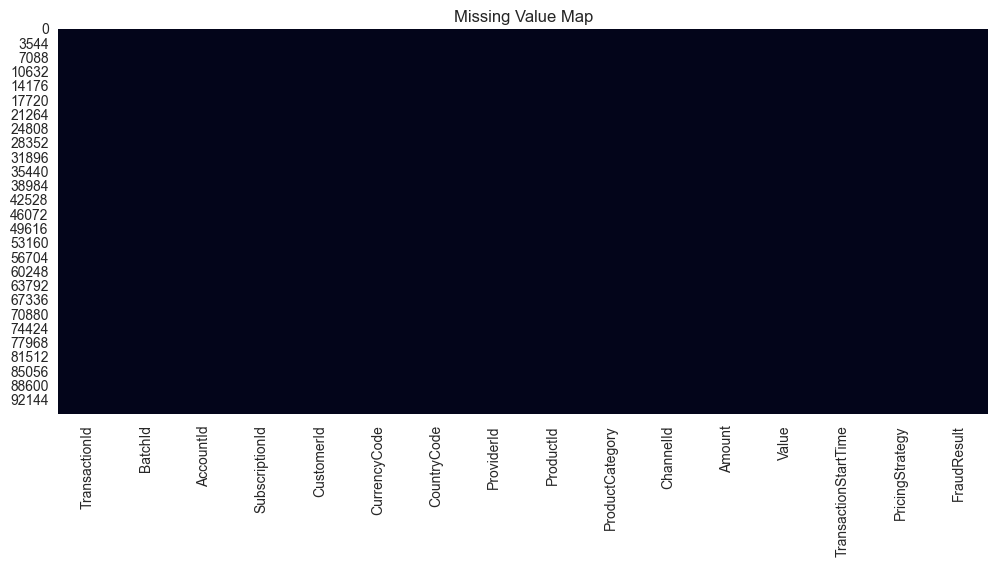

In [11]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Value Map")
plt.show()

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.00,256.00,0.00,256.00,256.00,256.00,256.00,256.00
Amount,95662.00,6717.85,123306.80,-1000000.00,-50.00,1000.00,2800.00,9880000.00
Value,95662.00,9900.58,123122.09,2.00,275.00,1000.00,5000.00,9880000.00
PricingStrategy,95662.00,2.26,0.73,0.00,2.00,2.00,2.00,4.00
FraudResult,95662.00,0.00,0.04,0.00,0.00,0.00,0.00,1.00


In [13]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns

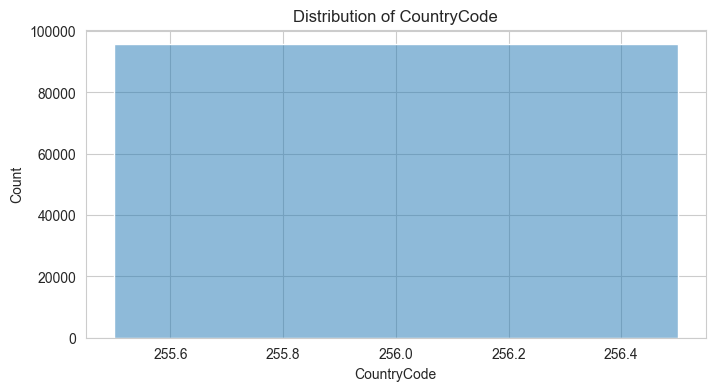

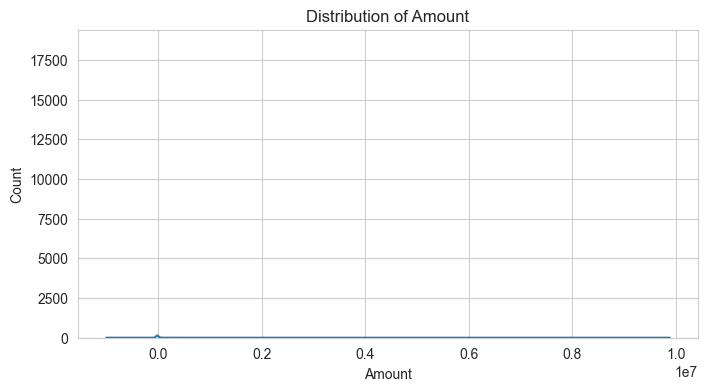

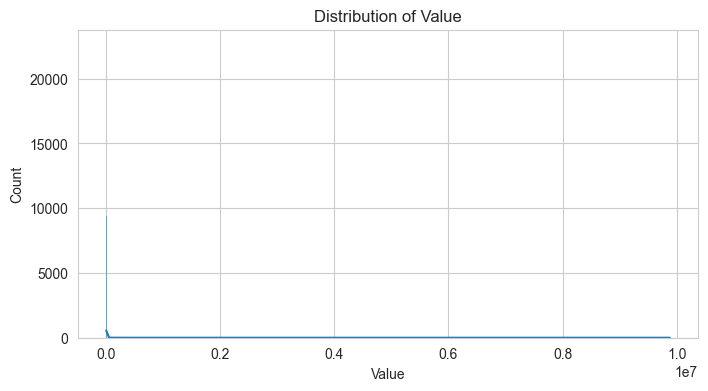

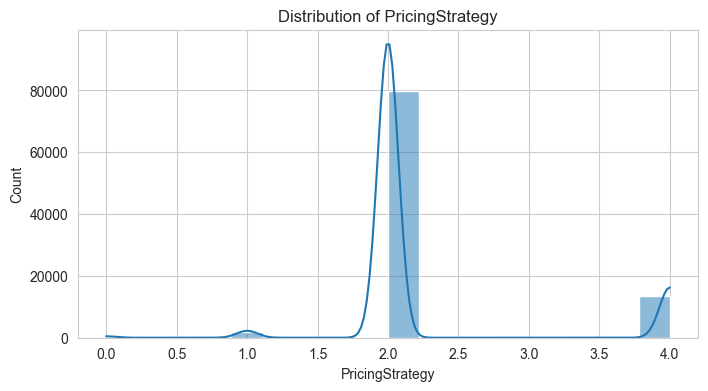

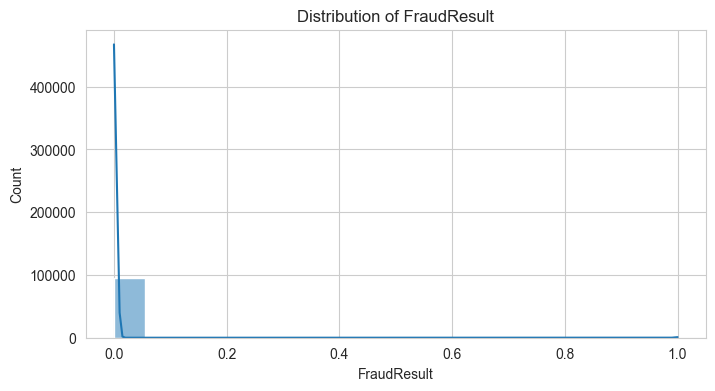

In [14]:
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()

In [15]:
df[numerical_cols].skew().sort_values(
    ascending=False
)

Value             51.29
Amount            51.10
FraudResult       22.20
PricingStrategy    1.66
CountryCode        0.00
dtype: float64

In [16]:
categorical_cols = [
    "CurrencyCode",
    "ProviderId",
    "ProductCategory",
    "ChannelId",
    "PricingStrategy"
]

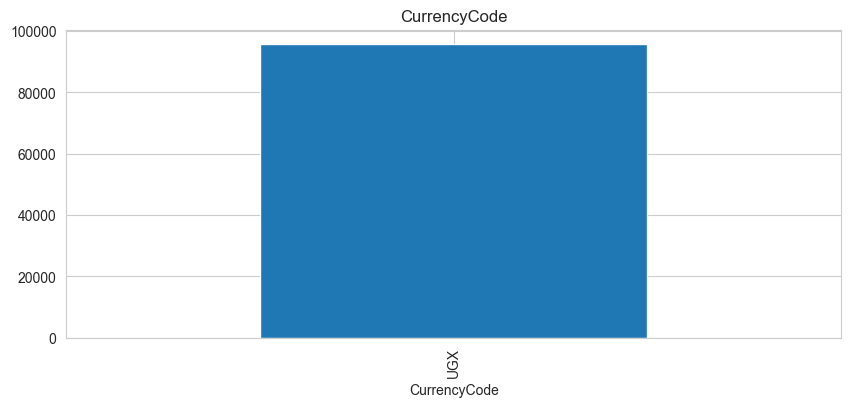

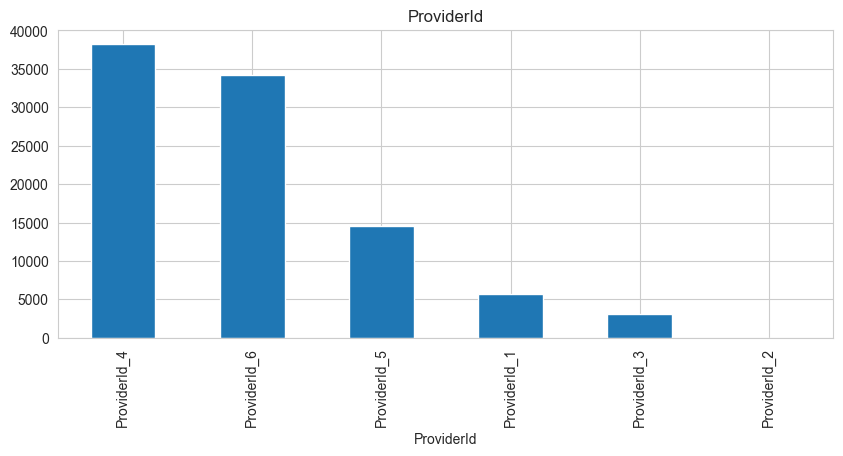

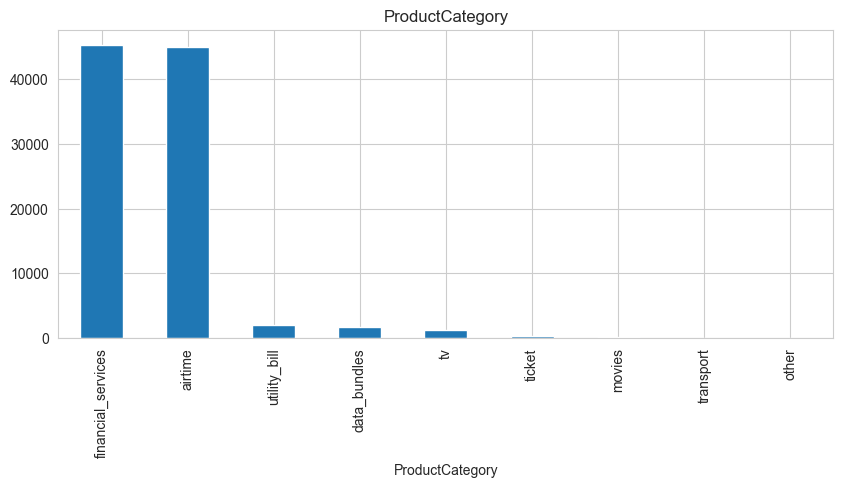

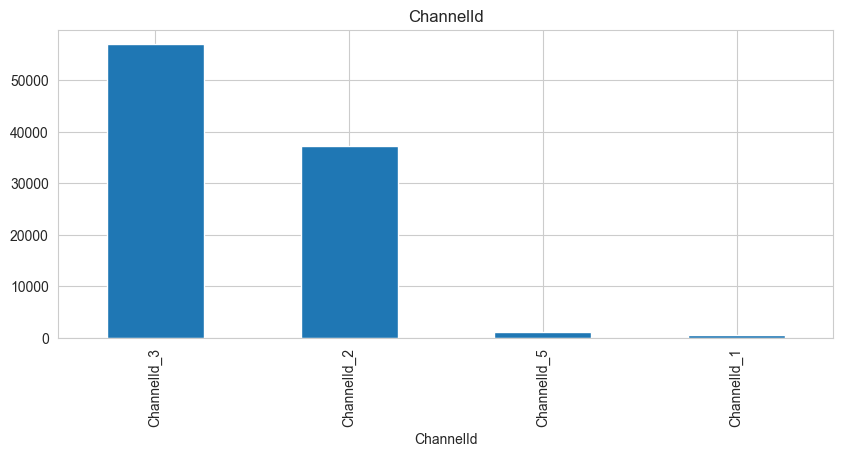

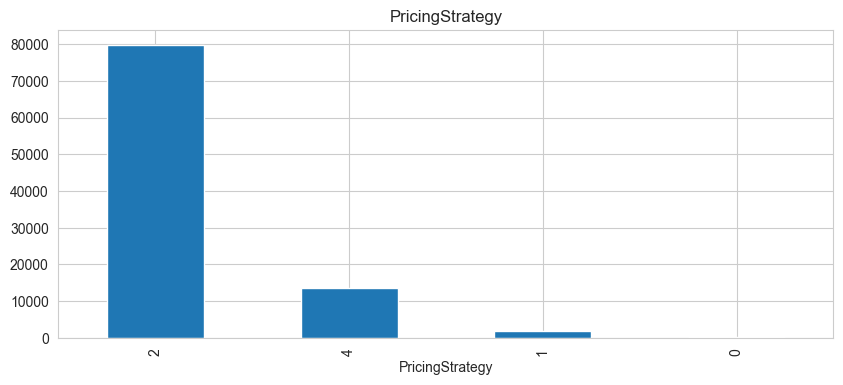

In [17]:
for col in categorical_cols:

    plt.figure(figsize=(10,4))

    df[col].value_counts().head(15).plot(
        kind="bar"
    )

    plt.title(col)

    plt.show()

In [18]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

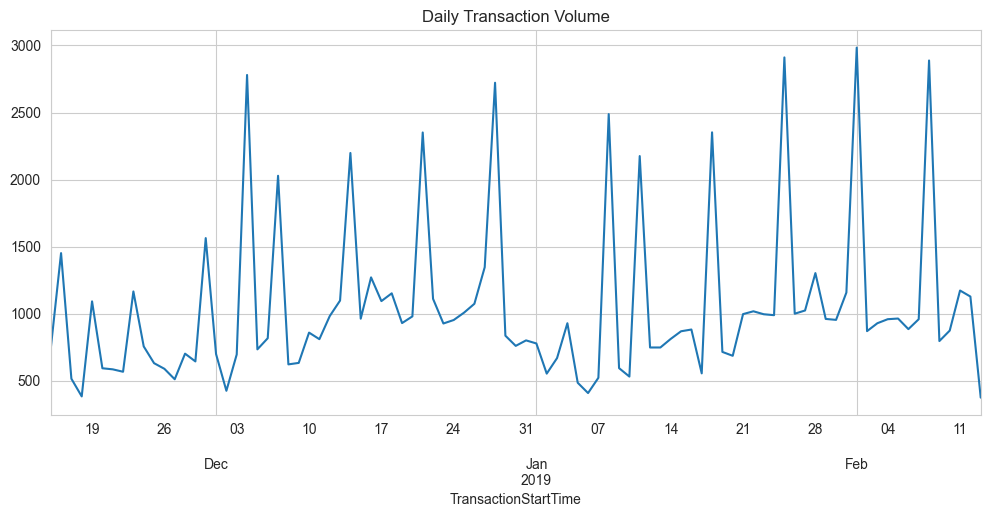

In [19]:
daily_transactions = (
    df
    .set_index("TransactionStartTime")
    .resample("D")
    .size()
)

daily_transactions.plot(
    figsize=(12,5)
)

plt.title(
    "Daily Transaction Volume"
)

plt.show()

In [20]:
df["Hour"] = (
    df["TransactionStartTime"]
    .dt.hour
)

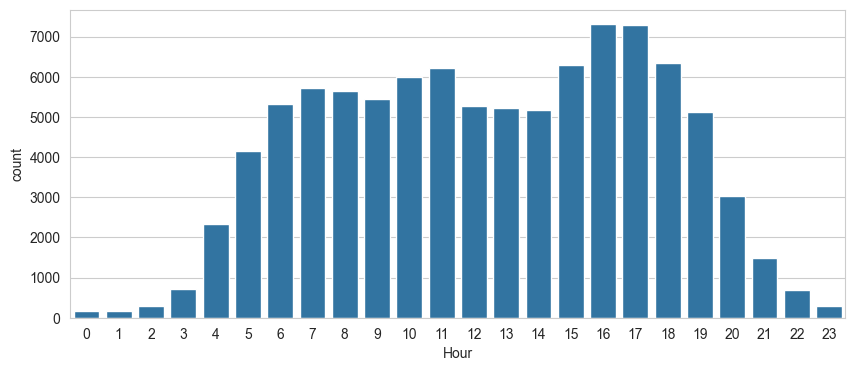

In [21]:
plt.figure(figsize=(10,4))

sns.countplot(
    x="Hour",
    data=df
)

plt.show()

In [22]:
df["FraudResult"].value_counts()

FraudResult
0    95469
1      193
Name: count, dtype: int64

In [23]:
(
df["FraudResult"]
.value_counts(normalize=True)
*100
)

FraudResult
0   99.80
1    0.20
Name: proportion, dtype: float64

<Axes: xlabel='FraudResult', ylabel='count'>

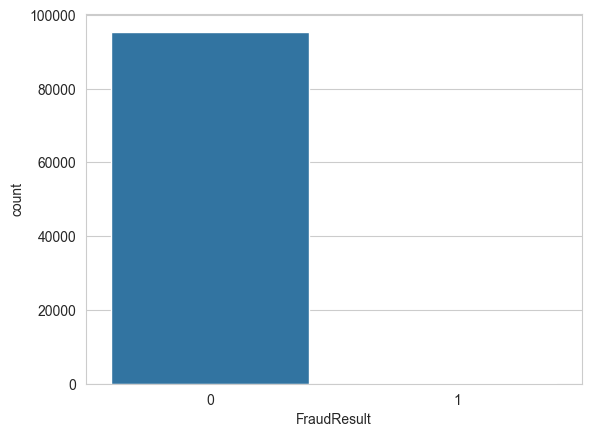

In [24]:
sns.countplot(
    x="FraudResult",
    data=df
)

In [25]:
corr = (
    df[numerical_cols]
    .corr()
)

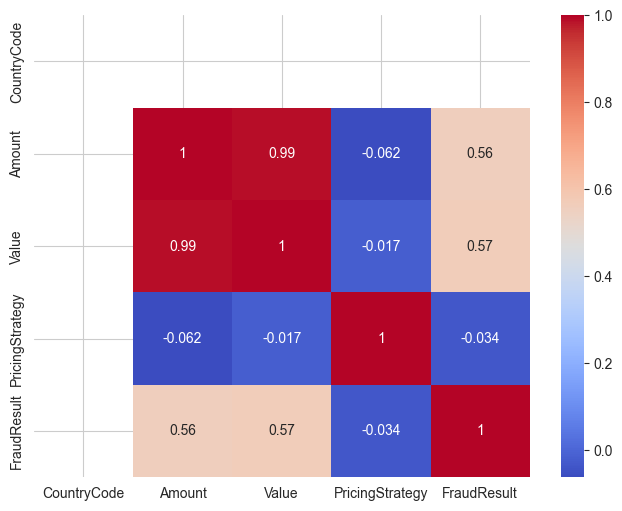

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

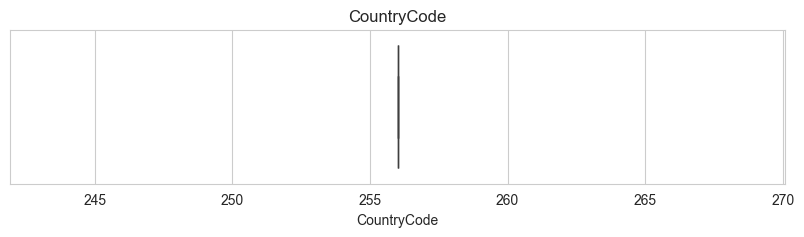

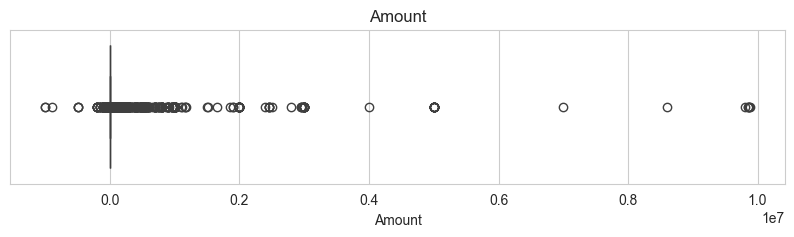

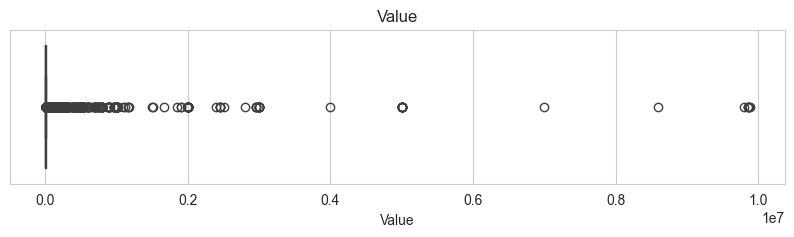

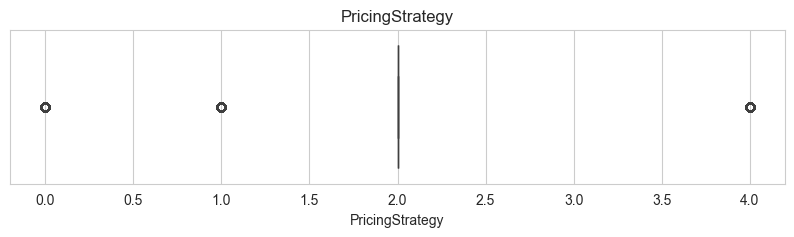

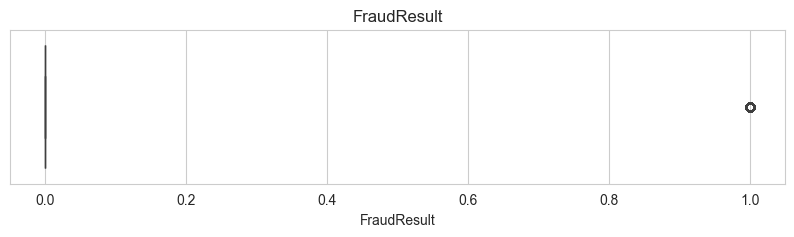

In [27]:
for col in numerical_cols:

    plt.figure(figsize=(10,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

Outliers are expected in transaction data because a small number of customers can generate exceptionally large transactions. These observations should not automatically be removed without business justification.

In [28]:
customer_summary = (
    df.groupby("CustomerId")
      .agg(
          transaction_count=("TransactionId","count"),
          total_amount=("Amount","sum"),
          avg_amount=("Amount","mean")
      )
)

In [29]:
customer_summary.describe()

,transaction_count,total_amount,avg_amount
count,3742.00,3742.00,3742.00
mean,25.56,171737.74,15715.62
std,96.93,2717304.82,167699.10
min,1.00,-104900000.00,-425000.00
25%,2.00,4077.44,1000.00
50%,7.00,20000.00,2583.85
75%,20.00,79967.75,4877.61
max,4091.00,83451240.00,8601821.14


# Key Insights

## 1. Customer Aggregation is Required
The dataset is recorded at the transaction level, while credit risk assessment is performed at the customer level. Aggregation strategies will therefore be necessary before model development.

## 2. Transaction Amounts are Highly Skewed
Amount and Value exhibit substantial positive skewness and contain extreme observations, suggesting that robust aggregation and possible transformations may improve model stability.

## 3. Temporal Features Appear Valuable
Transaction timestamps reveal meaningful behavioral patterns and provide opportunities to engineer recency, activity frequency, and transaction timing features.

## 4. Strong Correlation Exists Between Amount and Value
The high correlation between Amount and Value indicates potential redundancy that should be considered during feature selection.

## 5. Customer Behavior Varies Significantly
Large variation in transaction frequency and spending patterns supports the use of RFM analysis as a basis for customer segmentation and proxy risk label creation.

### Customer-Level Observations

The customer-level aggregates reveal substantial heterogeneity in user behavior.

- Transaction counts range from 1 to over 4,000 transactions.
- Total transaction amounts vary widely, indicating significant differences in customer engagement and purchasing power.
- The large standard deviations relative to the means suggest highly skewed distributions.

These findings support the use of customer behavioral segmentation techniques such as RFM analysis to identify meaningful risk groups and construct a proxy target variable for credit risk modeling.